# Notebook 05 — Feature Inspection

Validates Phase 5 features: distributions, correlations, and separability by relevance label.

In [1]:
import os, sys
from pathlib import Path

notebook_dir = Path().resolve()
project_root = notebook_dir.parent if notebook_dir.name == "notebooks" else notebook_dir
os.chdir(project_root)
sys.path.insert(0, str(project_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({"figure.dpi": 120, "font.size": 11})

print("Working directory:", os.getcwd())

Working directory: /Users/vraj21/Desktop/Projects/LLM Reranker


## 1  Load features

In [2]:
from src.utils.io import load_parquet

scifact_df  = load_parquet("data/interim/scifact/features.parquet")
nfcorpus_df = load_parquet("data/interim/nfcorpus/features.parquet")

print("SciFact shape:", scifact_df.shape)
print("NFCorpus shape:", nfcorpus_df.shape)
print("\nColumns:", list(scifact_df.columns))
scifact_df.describe().round(4)

SciFact shape: (6000, 10)
NFCorpus shape: (6460, 10)

Columns: ['query_id', 'doc_id', 'bm25_score', 'bm25_rank', 'is_relevant', 'relevance_label', 'lexical_overlap', 'query_term_freq', 'doc_length', 'doc_length_bucket']


,bm25_score,bm25_rank,relevance_label,lexical_overlap,query_term_freq,doc_length,doc_length_bucket
count,6000.0000,6000.0000,6000.0000,6000.0000,6000.0000,6000.0000,6000.0000
mean,23.9513,10.5000,0.0408,0.4500,0.0088,224.0478,1.5065
std,11.2314,5.7668,0.1979,0.1274,0.0043,90.9812,1.1175
min,5.4803,1.0000,0.0000,0.1000,0.0007,58.0000,0.0000
25%,16.4329,5.7500,0.0000,0.3636,0.0058,164.0000,1.0000
50%,21.4489,10.5000,0.0000,0.4444,0.0083,213.0000,2.0000
75%,29.5455,15.2500,0.0000,0.5385,0.0112,264.0000,3.0000
max,123.0353,20.0000,1.0000,1.0000,0.0377,1541.0000,3.0000


## 2  Feature distributions by relevance

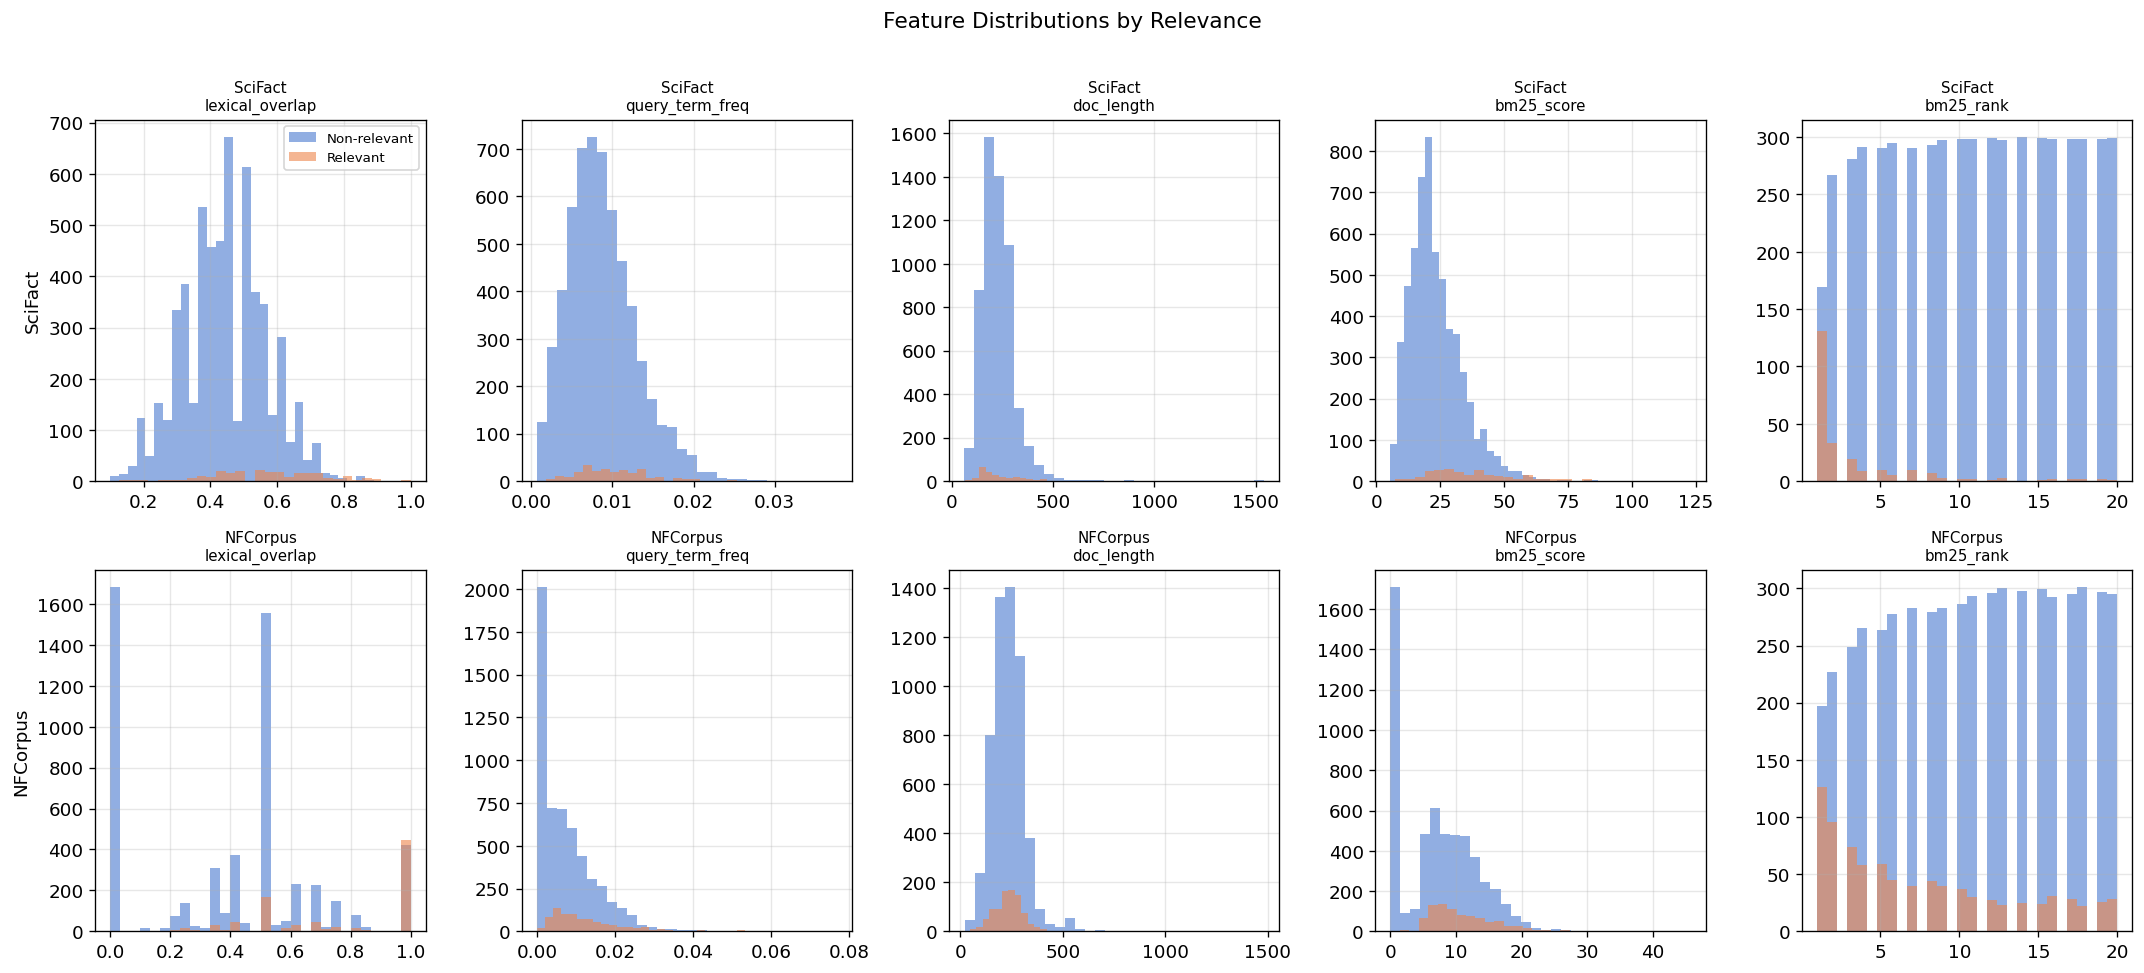

Saved.


In [3]:
cont_features = ["lexical_overlap", "query_term_freq", "doc_length", "bm25_score", "bm25_rank"]

fig, axes = plt.subplots(2, 5, figsize=(18, 8))

for row_idx, (df, name) in enumerate([(scifact_df, "SciFact"), (nfcorpus_df, "NFCorpus")]):
    for col_idx, feat in enumerate(cont_features):
        ax = axes[row_idx, col_idx]
        for label, color in [(False, "#4878d0"), (True, "#ee854a")]:
            grp = df[df["is_relevant"] == label][feat]
            ax.hist(grp, bins=30, alpha=0.6, color=color,
                    label="Relevant" if label else "Non-relevant")
        ax.set_title(f"{name}\n{feat}", fontsize=9)
        ax.set_xlabel("")
        if col_idx == 0:
            ax.set_ylabel(name)
        ax.grid(True, alpha=0.3)
        if row_idx == 0 and col_idx == 0:
            ax.legend(fontsize=8)

plt.suptitle("Feature Distributions by Relevance", y=1.01, fontsize=13)
plt.tight_layout()
Path("outputs/midproject/figures").mkdir(parents=True, exist_ok=True)
plt.savefig("outputs/midproject/figures/feature_distributions.png", bbox_inches="tight")
plt.show()
print("Saved.")

## 3  Correlation matrix (SciFact)

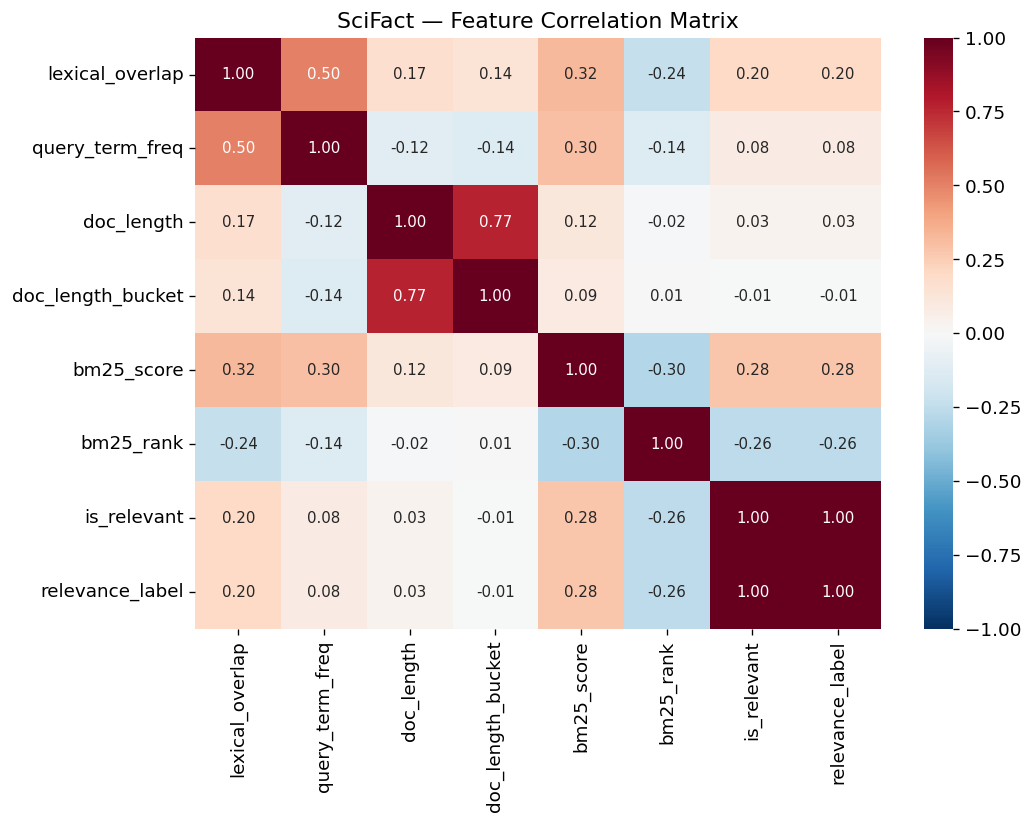

Saved.


In [4]:
import seaborn as sns

corr_cols = ["lexical_overlap", "query_term_freq", "doc_length", "doc_length_bucket",
             "bm25_score", "bm25_rank", "is_relevant", "relevance_label"]

corr = scifact_df[corr_cols].astype(float).corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, ax=ax, annot_kws={"size": 9})
ax.set_title("SciFact — Feature Correlation Matrix")
plt.tight_layout()
plt.savefig("outputs/midproject/figures/feature_correlation.png", bbox_inches="tight")
plt.show()
print("Saved.")

## 4  Doc length bucket distribution

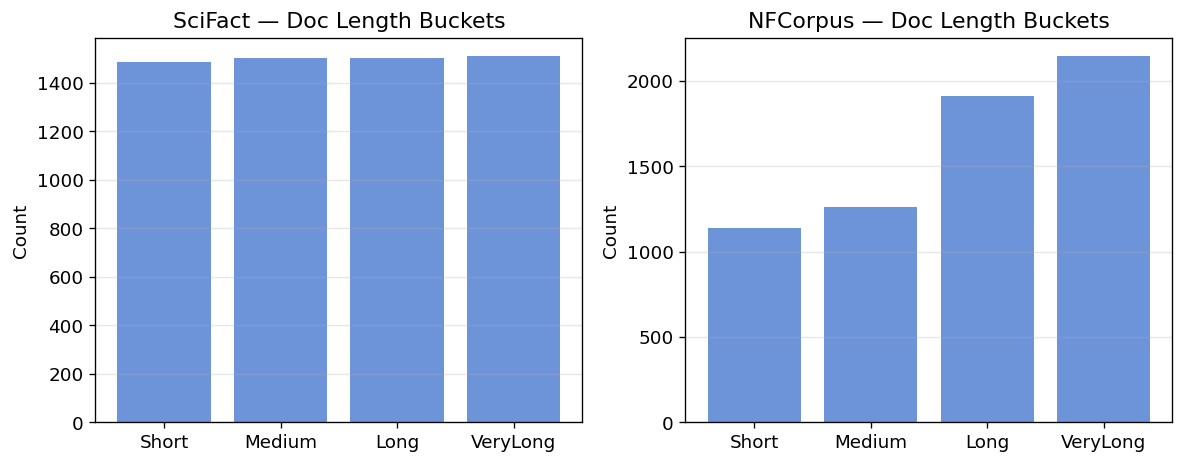

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
labels_map = {0: "Short", 1: "Medium", 2: "Long", 3: "VeryLong"}

for ax, (df, name) in zip(axes, [(scifact_df, "SciFact"), (nfcorpus_df, "NFCorpus")]):
    counts = df["doc_length_bucket"].value_counts().sort_index()
    ax.bar([labels_map[k] for k in counts.index], counts.values, color="#4878d0", alpha=0.8)
    ax.set_title(f"{name} — Doc Length Buckets")
    ax.set_ylabel("Count")
    ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("outputs/midproject/figures/doc_length_buckets.png", bbox_inches="tight")
plt.show()

## 5  Mean feature values: relevant vs non-relevant

In [6]:
feat_cols = ["lexical_overlap", "query_term_freq", "bm25_score"]

for name, df in [("SciFact", scifact_df), ("NFCorpus", nfcorpus_df)]:
    print(f"\n{name}:")
    print(df.groupby("is_relevant")[feat_cols].mean().round(4).to_string())


SciFact:
             lexical_overlap  query_term_freq  bm25_score
is_relevant                                              
False                 0.4447           0.0088     23.3049
True                  0.5744           0.0105     39.1350

NFCorpus:
             lexical_overlap  query_term_freq  bm25_score
is_relevant                                              
False                 0.3802           0.0071      7.0775
True                  0.7595           0.0132     11.2790
